<a href="https://colab.research.google.com/github/suryasridhar/regime-detection-and-optimization/blob/feature%2Fhmm/ETF_HMM_Regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
!pip install yfinance
!pip install pandas

In [99]:
!pip install numpy

In [100]:
!pip install scikit-learn

In [101]:
# 1. ETF Data Collection and Cleaning

import yfinance as yf
import pandas as pd
import numpy as np



In [220]:
# Define ETF universe
etfs = ["QQQ", "DIA", "IWM"]
base_etf = ["SPY"]
# Define time range
start_date = "2020-01-01"
end_date = "2024-12-31"

In [221]:
# Download adjusted close prices
raw_data = yf.download(etfs, start=start_date, end=end_date, auto_adjust=False)
base_data = yf.download(base_etf, start_date, end_date, auto_adjust=False)['Adj Close']
adj_close = pd.DataFrame(raw_data['Adj Close'])
raw_data.head()

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


Price        Adj Close                               Close              \
Ticker             DIA         IWM         QQQ         DIA         IWM   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080  288.619995  165.779999   
2020-01-03  258.222137  154.052536  207.175812  286.320007  165.130005   
2020-01-06  258.817505  154.257751  208.510696  286.980011  165.350006   
2020-01-07  257.699036  153.744659  208.481705  285.739990  164.800003   
2020-01-08  259.196075  154.220413  210.048706  287.399994  165.309998   

Price                         High                                 Low  \
Ticker             QQQ         DIA         IWM         QQQ         DIA   
Date                                                                     
2020-01-02  216.160004  288.630005  166.750000  216.160004  286.149994   
2020-01-03  214.179993  287.109985  165.410004  215.470001  285.179993   
2020-01-06  215.559998  287.029999  165.539993  215.589996  284.160004   
2020-01-07  215.529999  286.790009  165.339996  216.139999  285.579987   
2020-01-08  217.149994  288.670013  166.029999  218.139999  285.079987   

Price                                     Open                          \
Ticker             IWM         QQQ         DIA         IWM         QQQ   
Date                                                                     
2020-01-02  164.229996  213.979996  286.440002  166.740005  214.399994   
2020-01-03  163.699997  213.279999  285.339996  163.740005  213.300003   
2020-01-06  163.539993  212.240005  284.290009  163.850006  212.500000   
2020-01-07  164.210007  214.850006  286.299988  164.850006  215.639999   
2020-01-08  164.720001  215.160004  285.320007  164.820007  215.500000   

Price        Volume                      
Ticker          DIA       IWM       QQQ  
Date                                     
2020-01-02  3865500  18297500  30969400  
2020-01-03  3296700  19295600  27518900  
2020-01-06  1645100  17150900  21655300  
2020-01-07  1413000  11817900  22139300  
2020-01-08  3136700  13832400  26397300

In [222]:
#Setup multiindex data
data = adj_close.dropna()
multi_cols = pd.MultiIndex.from_product([etfs, ['adj_close']], names=('ticker','feature'))
data.columns = multi_cols
data

ticker,QQQ,DIA,IWM
feature,adj_close,adj_close,adj_close
Date,,,
2020-01-02,260.296478,154.658905,209.091080
2020-01-03,258.222137,154.052536,207.175812
2020-01-06,258.817505,154.257751,208.510696
2020-01-07,257.699036,153.744659,208.481705
2020-01-08,259.196075,154.220413,210.048706
...,...,...,...
2024-12-23,425.102356,220.305115,521.505737
2024-12-24,428.680481,222.275223,528.577271


In [223]:
#Get log returns and gets log return relative to SPY
returns = np.log(data / data.shift(1)).dropna()
base_etf_log_returns = np.log(base_data / base_data.shift(1)).dropna()['SPY']
returns_relative = returns.sub(base_etf_log_returns, axis=0)

for ticker in etfs:
    data[(ticker, 'log_return')] = returns[ticker]
    data[(ticker, 'relative_spy')] = returns_relative[ticker]
data.head()


ticker             QQQ         DIA         IWM        QQQ               \
feature      adj_close   adj_close   adj_close log_return relative_spy   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080        NaN          NaN   
2020-01-03  258.222137  154.052536  207.175812  -0.008001    -0.000400   
2020-01-06  258.817505  154.257751  208.510696   0.002303    -0.001505   
2020-01-07  257.699036  153.744659  208.481705  -0.004331    -0.001515   
2020-01-08  259.196075  154.220413  210.048706   0.005792     0.000477   

ticker            DIA                     IWM               
feature    log_return relative_spy log_return relative_spy  
Date                                                        
2020-01-02        NaN          NaN        NaN          NaN  
2020-01-03  -0.003928     0.003673  -0.009202    -0.001601  
2020-01-06   0.001331    -0.002477   0.006423     0.002615  
2020-01-07  -0.003332    -0.000516  -0.000139     0.002677  
2020-01-08   0.003090    -0.002226   0.007488     0.002172

In [224]:
#Get ATR with 14-day moving average
prev_close = data.xs('adj_close', level = 1, axis =1).shift(1)
p1 = (raw_data['High'] - raw_data['Low']).dropna()
p2 = abs(raw_data['High'] - prev_close)
p3 = abs(prev_close - raw_data['Low'])
tr_df = pd.concat([p1, p2, p3], axis=1, keys=['HL_range', 'High_prev', 'Prev_Low']).swaplevel(axis=1).dropna()
atr = pd.DataFrame({ticker: tr_df[ticker].max(axis=1) for ticker in etfs}).rolling(window=14).mean()
for ticker in etfs:
    data[(ticker, 'atr')] = atr[ticker]


In [225]:
#Volume z-score
vol_data = raw_data['Volume']
volume_z = (vol_data - vol_data.rolling(window=20).mean())/vol_data.rolling(window=20).std()
for ticker in etfs:
    data[(ticker, 'volume_z')] = volume_z[ticker]


In [226]:
#skew, kurtosis, rolling mean
skew_returns = returns.rolling(14).skew()
kurtosis_returns = returns.rolling(14).kurt()
mean_rolling = returns.rolling(14).mean()
for ticker in etfs:
  data[(ticker, 'skew_returns')] = skew_returns[ticker]
  data[(ticker, 'kurtosis_returns')] = kurtosis_returns[ticker]
  data[(ticker, 'rolling_mean')] = mean_rolling[ticker]
data

ticker             QQQ         DIA         IWM        QQQ               \
feature      adj_close   adj_close   adj_close log_return relative_spy   
Date                                                                     
2020-01-02  260.296478  154.658905  209.091080        NaN          NaN   
2020-01-03  258.222137  154.052536  207.175812  -0.008001    -0.000400   
2020-01-06  258.817505  154.257751  208.510696   0.002303    -0.001505   
2020-01-07  257.699036  153.744659  208.481705  -0.004331    -0.001515   
2020-01-08  259.196075  154.220413  210.048706   0.005792     0.000477   
...                ...         ...         ...        ...          ...   
2024-12-23  425.102356  220.305115  521.505737   0.000816    -0.005154   
2024-12-24  428.680481  222.275223  528.577271   0.008382    -0.002672   
2024-12-26  429.384186  224.553787  528.218201   0.001640     0.001574   
2024-12-27  426.202545  221.280228  521.196533  -0.007437     0.003145   
2024-12-30  422.009888  219.578751  514.264648  -0.009886     0.001591   

ticker            DIA                     IWM                     QQQ  ...  \
feature    log_return relative_spy log_return relative_spy        atr  ...   
Date                                                                   ...   
2020-01-02        NaN          NaN        NaN          NaN        NaN  ...   
2020-01-03  -0.003928     0.003673  -0.009202    -0.001601        NaN  ...   
2020-01-06   0.001331    -0.002477   0.006423     0.002615        NaN  ...   
2020-01-07  -0.003332    -0.000516  -0.000139     0.002677        NaN  ...   
2020-01-08   0.003090    -0.002226   0.007488     0.002172        NaN  ...   
...               ...          ...        ...          ...        ...  ...   
2024-12-23  -0.002301    -0.008271   0.009696     0.003725  94.001354  ...   
2024-12-24   0.008903    -0.002151   0.013469     0.002415  95.721586  ...   
2024-12-26   0.010199     0.010132  -0.000680    -0.000746  97.449408  ...   
2024-12-27  -0.014685    -0.004103  -0.013382    -0.002800  98.433149  ...   
2024-12-30  -0.007719     0.003758  -0.013389    -0.001912  99.056850  ...   

ticker           IWM          QQQ                                        DIA  \
feature     volume_z skew_returns kurtosis_returns rolling_mean skew_returns   
Date                                                                           
2020-01-02       NaN          NaN              NaN          NaN          NaN   
2020-01-03       NaN          NaN              NaN          NaN          NaN   
2020-01-06       NaN          NaN              NaN          NaN          NaN   
2020-01-07       NaN          NaN              NaN          NaN          NaN   
2020-01-08       NaN          NaN              NaN          NaN          NaN   
...              ...          ...              ...          ...          ...   
2024-12-23  0.144345    -1.270837         4.960230    -0.002890    -2.084122   
2024-12-24 -1.112565    -1.177941         4.611115    -0.002776    -1.948520   
2024-12-26 -0.553218    -1.337542         4.799822    -0.002299    -2.039325   
2024-12-27 -0.015682    -1.192037         4.178478    -0.002587    -1.718777   
2024-12-30 -0.159339    -1.013393         3.278112    -0.002962    -1.665659   

ticker                                            IWM                   \
feature    kurtosis_returns rolling_mean skew_returns kurtosis_returns   
Date                                                                     
2020-01-02              NaN          NaN          NaN              NaN   
2020-01-03              NaN          NaN          NaN              NaN   
2020-01-06              NaN          NaN          NaN              NaN   
2020-01-07              NaN          NaN          NaN              NaN   
2020-01-08              NaN          NaN          NaN              NaN   
...                     ...          ...          ...              ...   
2024-12-23         5.900623    -0.005556    -1.518532         3.478583   
2024-12-2

In [227]:
#Flattening it out in prep for HMM
features = ['log_return', 'atr', 'relative_spy', 'atr', 'volume_z', 'skew_returns', 'kurtosis_returns', 'rolling_mean']
flattened_standard = pd.concat(
    [data[ticker][features] for ticker in etfs],
    axis=1,
    keys=etfs
)

# rename to ticker_feature format
flattened_standard.columns = [
    f"{ticker}_{feature}" for ticker in etfs for feature in features
]

# drop rows with NaN


In [228]:
#vix
vix = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)['Adj Close']
vix = vix.loc[flattened_standard.index]
flattened_standard['vix'] = vix.values
flattened_standard = flattened_standard.dropna()

[*********************100%***********************]  1 of 1 completed


# Markov Model for identifying low or high volatility regimes

In [229]:
flattened_standard = flattened_standard.dropna()



In [230]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scale = scaler.fit_transform(flattened_standard)
X_scale = pd.DataFrame(X_scale, index = flattened_standard.index, columns = flattened_standard.columns)

In [231]:
from sklearn.decomposition import PCA
pca = PCA()
data_with_pca = pca.fit_transform(X_scale)
print(pca.explained_variance_ratio_)

[2.27491445e-01 1.70551358e-01 9.37600109e-02 9.10323495e-02
 8.51616670e-02 6.71163066e-02 5.33460805e-02 3.41413808e-02
 3.23574348e-02 2.58337636e-02 1.98286836e-02 1.82526614e-02
 1.61469235e-02 1.40950814e-02 1.24689906e-02 1.05210116e-02
 9.83143479e-03 8.74792192e-03 5.51946886e-03 3.79602590e-03
 3.19355082e-17 1.83356945e-18 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


In [232]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
k = np.argmax(cum_var > 0.9) + 1
data_with_pca_reduced = data_with_pca[:, :k]
data_with_pca_reduced = pd.DataFrame(data_with_pca_reduced)
data_with_pca_reduced.index = flattened_standard.index

In [233]:
data_with_pca_reduced

,0,1,2,3,4,5,6,7,8,9,10
Date,,,,,,,,,,,
2020-01-30,-1.677005,-1.134338,2.642997,-0.256324,-0.038298,0.854843,-1.120707,-0.358589,-0.841053,0.230757,1.560194
2020-01-31,-2.209130,-3.665054,2.264088,-0.083231,-0.865951,1.800935,-2.356839,0.241869,0.691010,1.107712,1.041047
2020-02-03,-1.780619,0.583175,1.837812,1.419707,-0.548602,-0.546464,-0.375737,0.112674,0.029503,1.201485,1.142873
2020-02-04,-1.609623,1.401331,1.538871,1.355624,-0.036906,-0.088429,-0.615411,0.196995,-0.738268,0.895528,1.083061
2020-02-05,-1.596723,0.500395,1.496238,-1.198578,1.419666,-0.823115,-0.871239,0.184467,-1.033434,0.521724,0.939102
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,5.742529,-2.694259,4.271473,2.420874,-3.663767,-1.527047,1.911060,1.792999,-0.527414,1.031397,-1.604792
2024-12-24,6.011292,-1.301211,3.828351,2.197795,-3.169101,-2.757501,2.501436,1.460653,-0.557020,1.028435,-1.387544
2024-12-26,6.088834,-1.935669,4.426450,0.792090,-2.537069,-3.203265,2.365971,1.416289,0.500296,1.292520,-1.490238


In [234]:
#vix
vix = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)['Adj Close']
vix = vix.loc[data_with_pca_reduced.index]
data_with_pca_reduced['vix_scaled'] = scaler.fit_transform(vix.values)
data_with_pca_reduced

[*********************100%***********************]  1 of 1 completed


,0,1,2,3,4,5,6,7,8,9,10,vix_scaled
Date,,,,,,,,,,,,
2020-01-30,-1.677005,-1.134338,2.642997,-0.256324,-0.038298,0.854843,-1.120707,-0.358589,-0.841053,0.230757,1.560194,-0.731472
2020-01-31,-2.209130,-3.665054,2.264088,-0.083231,-0.865951,1.800935,-2.356839,0.241869,0.691010,1.107712,1.041047,-0.326112
2020-02-03,-1.780619,0.583175,1.837812,1.419707,-0.548602,-0.546464,-0.375737,0.112674,0.029503,1.201485,1.142873,-0.431385
2020-02-04,-1.609623,1.401331,1.538871,1.355624,-0.036906,-0.088429,-0.615411,0.196995,-0.738268,0.895528,1.083061,-0.663710
2020-02-05,-1.596723,0.500395,1.496238,-1.198578,1.419666,-0.823115,-0.871239,0.184467,-1.033434,0.521724,0.939102,-0.772613
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,5.742529,-2.694259,4.271473,2.420874,-3.663767,-1.527047,1.911060,1.792999,-0.527414,1.031397,-1.604792,-0.575378
2024-12-24,6.011292,-1.301211,3.828351,2.197795,-3.169101,-2.757501,2.501436,1.460653,-0.557020,1.028435,-1.387544,-0.879095
2024-12-26,6.088834,-1.935669,4.426450,0.792090,-2.537069,-3.203265,2.365971,1.416289,0.500296,1.292520,-1.490238,-0.823434


In [235]:
!pip install hmmlearn

In [263]:
from hmmlearn.hmm import GaussianHMM
n_states = 2
hmm_data = data_with_pca_reduced
model = GaussianHMM(
    n_components=n_states,
    covariance_type='full',
    n_iter=100000,
    tol = 1e-4,
    random_state=42
)
model.fit(hmm_data)
regimes = model.predict(data_with_pca_reduced)
state_probs = model.predict_proba(data_with_pca_reduced)
data_with_pca_reduced['regime'] = (regimes)


In [264]:
print(model.transmat_)

[[0.99218778 0.00781222]
 [0.01349945 0.98650055]]


In [265]:
!pip install matplotlib

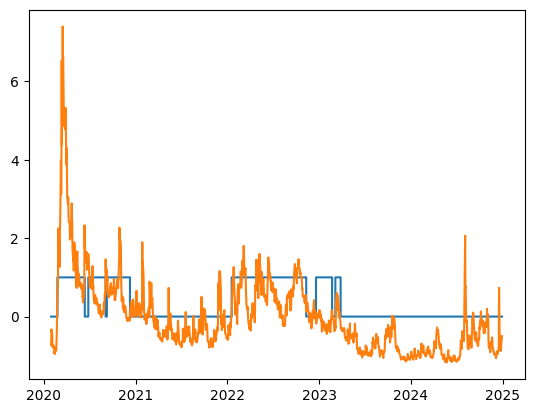

In [266]:
import matplotlib.pyplot as plt
latest = data_with_pca_reduced
latest
plt.plot(latest.index, latest['regime'], drawstyle = 'steps-post')
plt.plot(latest.index, latest['vix_scaled'])